# SmartCart Clustering

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder , LabelEncoder , StandardScaler

In [2]:
df = pd.read_csv("smartcart_customers.csv")

In [3]:
df

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,172,88,88,3,8,10,4,7,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,2,1,6,2,1,1,2,5,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,111,21,42,1,8,2,10,4,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,10,3,5,2,2,0,4,6,0,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,46,27,15,5,5,3,6,5,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,10870,1967,Graduation,Married,61223.0,0,1,13-06-2013,46,709,...,42,118,247,2,9,3,4,5,0,0
2236,4001,1946,PhD,Together,64014.0,2,1,10-06-2014,56,406,...,0,0,8,7,8,2,5,7,0,0
2237,7270,1981,Graduation,Divorced,56981.0,0,0,25-01-2014,91,908,...,32,12,24,1,2,3,13,6,0,0
2238,8235,1956,Master,Together,69245.0,0,1,24-01-2014,8,428,...,80,30,61,2,6,5,10,3,0,0


In [4]:
df.info()
## no null values found

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 22 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

## Data Preprocessing

In [5]:
# checking object and integet/ float types
str_cols = df.select_dtypes(include=["object"]).columns
str_cols

Index(['Education', 'Marital_Status', 'Dt_Customer'], dtype='object')

In [6]:
int_cols = df.select_dtypes(include=["int64","float64"]).columns
int_cols

Index(['ID', 'Year_Birth', 'Income', 'Kidhome', 'Teenhome', 'Recency',
       'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts',
       'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases',
       'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases',
       'NumWebVisitsMonth', 'Complain', 'Response'],
      dtype='object')

In [7]:
# Handling Null Values
print(df["Income"].mean())
df["Income"] = df["Income"].fillna(df["Income"].mean())

52247.25135379061


### Feature Engineering

In [8]:
df['Dt_Customer'].unique()

array(['04-09-2012', '08-03-2014', '21-08-2013', '10-02-2014',
       '19-01-2014', '09-09-2013', '13-11-2012', '08-05-2013',
       '06-06-2013', '13-03-2014', '15-11-2013', '10-10-2012',
       '24-11-2012', '24-12-2012', '31-08-2012', '28-03-2013',
       '03-11-2012', '08-08-2012', '06-01-2013', '23-12-2012',
       '11-01-2014', '18-03-2013', '02-01-2013', '27-05-2013',
       '20-02-2013', '31-05-2013', '22-11-2013', '22-05-2014',
       '11-05-2013', '29-10-2012', '29-08-2013', '31-12-2013',
       '02-09-2013', '11-02-2014', '01-02-2013', '29-04-2013',
       '12-03-2013', '05-11-2013', '02-10-2013', '28-06-2014',
       '09-11-2012', '24-05-2013', '01-01-2014', '08-11-2012',
       '12-05-2014', '11-08-2012', '07-06-2014', '12-06-2013',
       '19-11-2012', '02-04-2013', '28-04-2014', '17-06-2013',
       '03-03-2014', '04-07-2013', '07-09-2012', '18-02-2013',
       '11-06-2013', '06-12-2013', '21-05-2013', '11-05-2014',
       '19-03-2014', '27-09-2013', '08-04-2013', '11-09

In [9]:
# Convert the date string to a pandas datetime object
df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'], format='%d-%m-%Y')

# Calculate how many days they have been a customer
max_date = df['Dt_Customer'].max()
df['Days_as_Customer'] = (max_date - df['Dt_Customer']).dt.days

In [10]:
# Now calculate the Age 
max_year = df['Dt_Customer'].dt.year.max() 
df["Age"] = max_year - df["Year_Birth"]

# Verify the changes
df[['Year_Birth', 'Age']].head()

,Year_Birth,Age
0,1957,57
1,1954,60
2,1965,49
3,1984,30
4,1981,33


In [11]:
# Spending
df["Total_spending"] = df['MntWines'] + df['MntFruits'] + df['MntMeatProducts'] + df['MntFishProducts'] + df['MntSweetProducts'] + df['MntGoldProds']

In [12]:
# children
df["total_children"] = df["Kidhome"] + df["Teenhome"]

In [13]:
# Education column
df["Education"].value_counts()

df["Education"] = df["Education"].replace({
    "Basic" : "UnderGraduate" , "2n Cycle":"UnderGraduate",
    "Graduation":"Graduate",
    "Master":"PostGraduate" , "PhD":"PostGraduate"
})

In [14]:
# Marital_status column
df["Marital_Status"].value_counts()

df["Living_with"] = df["Marital_Status"].replace({
    "Married" : "Partner" , "Together":"Partner",
    "Single":"Alone", "Divorced":"Alone",
    "Widow":"Alone" , "Absurd":"Alone" , "YOLO":"Alone"
})

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 27 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   ID                   2240 non-null   int64         
 1   Year_Birth           2240 non-null   int64         
 2   Education            2240 non-null   object        
 3   Marital_Status       2240 non-null   object        
 4   Income               2240 non-null   float64       
 5   Kidhome              2240 non-null   int64         
 6   Teenhome             2240 non-null   int64         
 7   Dt_Customer          2240 non-null   datetime64[ns]
 8   Recency              2240 non-null   int64         
 9   MntWines             2240 non-null   int64         
 10  MntFruits            2240 non-null   int64         
 11  MntMeatProducts      2240 non-null   int64         
 12  MntFishProducts      2240 non-null   int64         
 13  MntSweetProducts     2240 non-nul

In [16]:
df_cleaned = df.drop(columns = {"ID","Dt_Customer" , "Year_Birth",'Kidhome', 'Teenhome','MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts','MntSweetProducts', 'MntGoldProds','Marital_Status'})

In [17]:
print(df_cleaned.shape)
print(df.shape)
df_cleaned

(2240, 15)
(2240, 27)


,Education,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Days_as_Customer,Age,Total_spending,total_children,Living_with
0,Graduate,58138.0,58,3,8,10,4,7,0,1,663,57,1617,0,Alone
1,Graduate,46344.0,38,2,1,1,2,5,0,0,113,60,27,2,Alone
2,Graduate,71613.0,26,1,8,2,10,4,0,0,312,49,776,0,Partner
3,Graduate,26646.0,26,2,2,0,4,6,0,0,139,30,53,1,Partner
4,PostGraduate,58293.0,94,5,5,3,6,5,0,0,161,33,422,1,Partner
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,Graduate,61223.0,46,2,9,3,4,5,0,0,381,47,1341,1,Partner
2236,PostGraduate,64014.0,56,7,8,2,5,7,0,0,19,68,444,3,Partner
2237,Graduate,56981.0,91,1,2,3,13,6,0,0,155,33,1241,0,Alone
2238,PostGraduate,69245.0,8,2,6,5,10,3,0,0,156,58,843,1,Partner


### Outliers

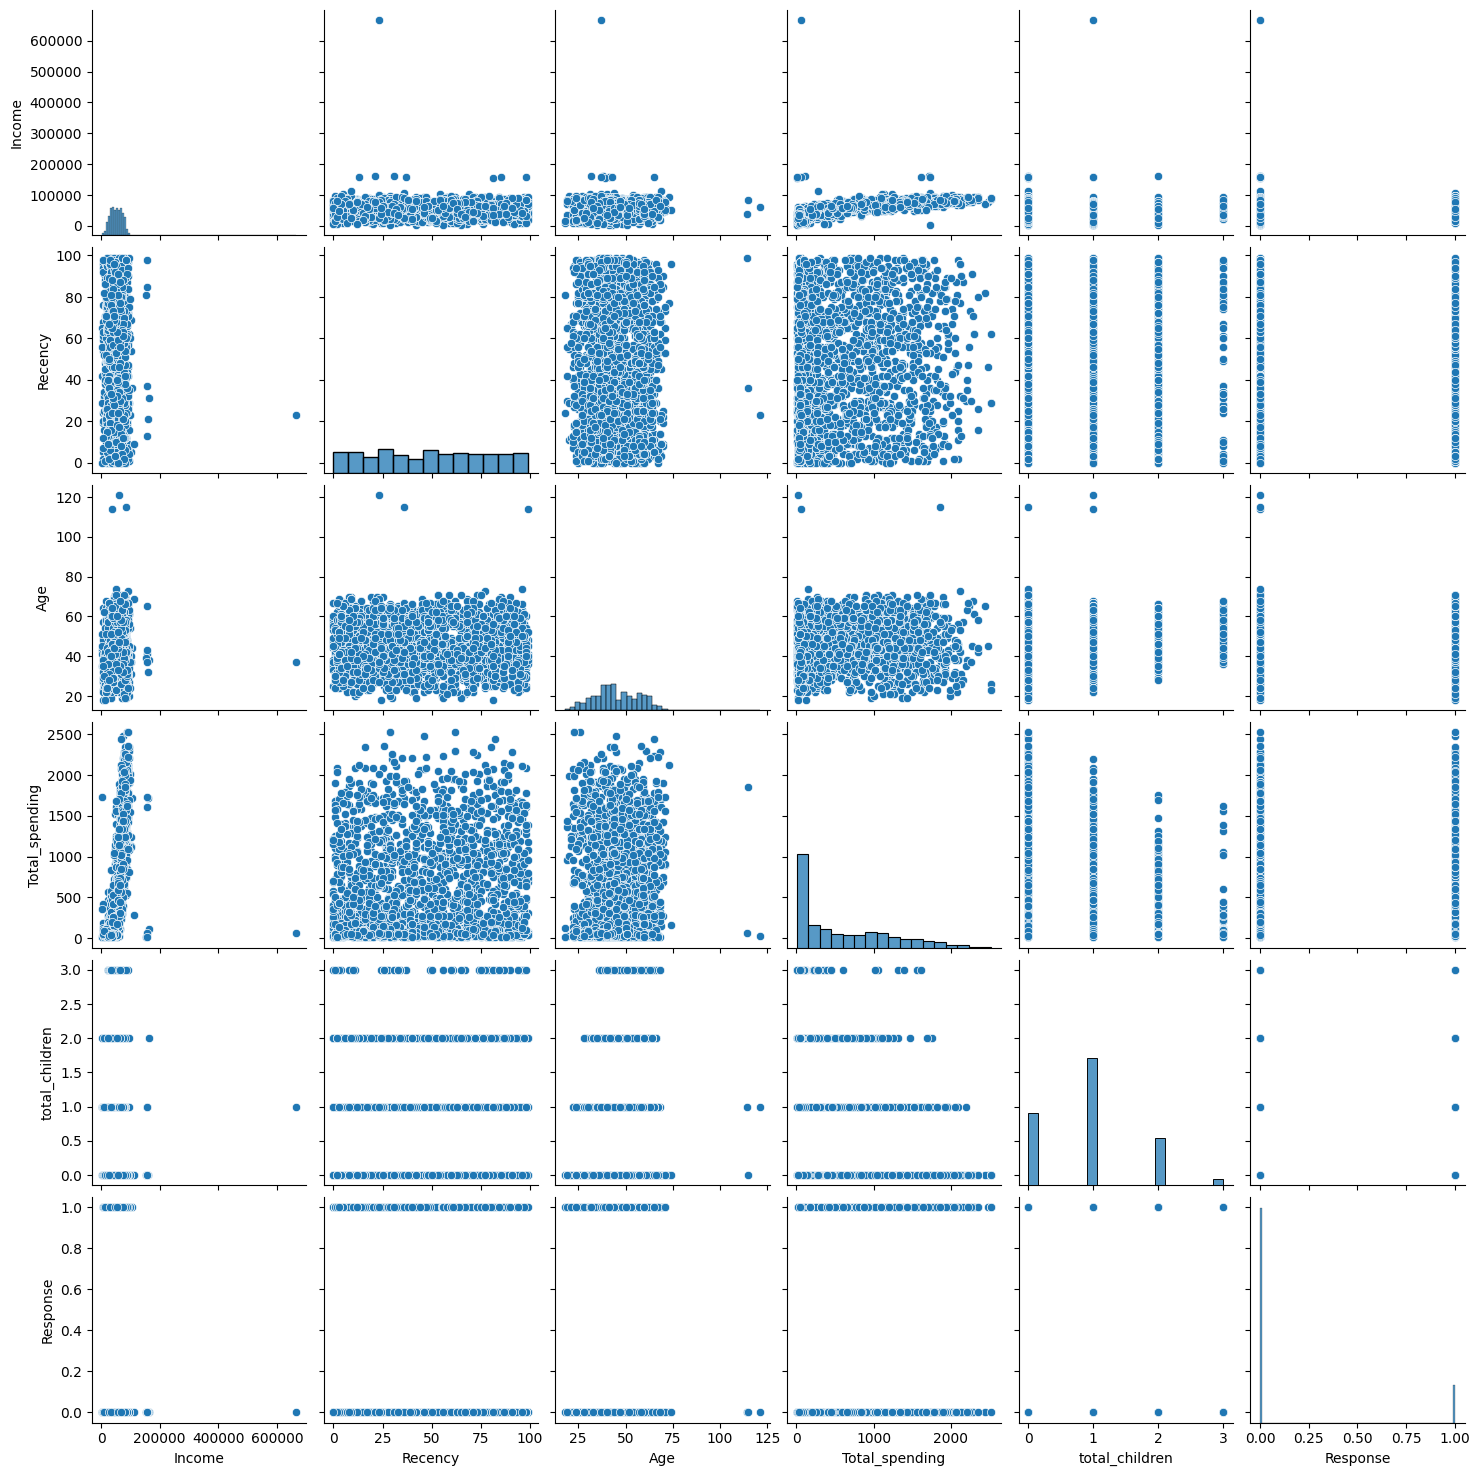

In [18]:
cols = ['Income', 'Recency','Age','Total_spending','total_children', 'Response']

# relative plots of some features
sns.pairplot(df_cleaned[cols])

In [19]:
# Remove outliers

print("data size with outliers:", len(df_cleaned))

df_cleaned = df_cleaned[ (df_cleaned["Age"] < 90) ]
df_cleaned = df_cleaned[ (df_cleaned["Income"] < 600_000) ]

print("data size without outliers:", len(df_cleaned))

data size with outliers: 2240
data size without outliers: 2236


## HeatMap

In [20]:
corr = df_cleaned.corr(numeric_only=True)

<Axes: >

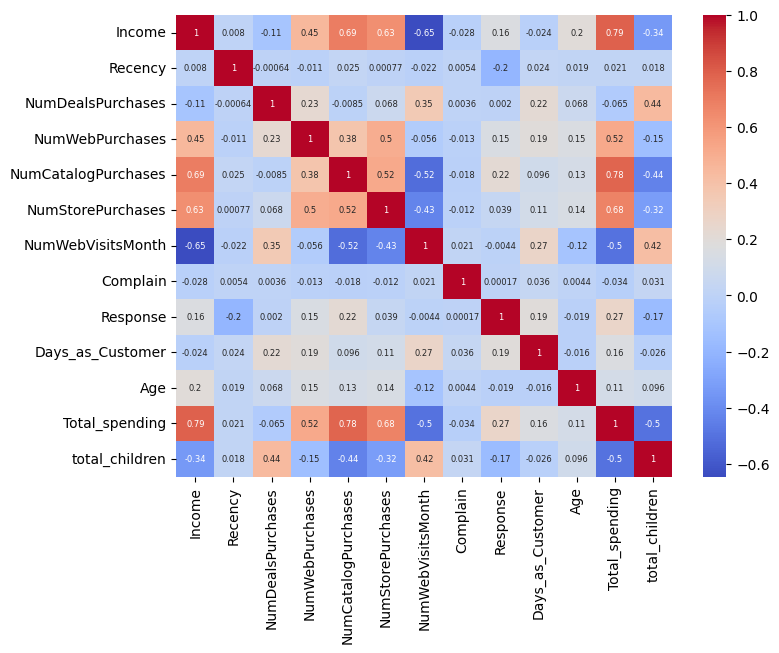

In [21]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    corr,
    annot=True,
    annot_kws={"size": 6},
    cmap="coolwarm"
)

## ENCODING

In [22]:
from sklearn.preprocessing import OneHotEncoder

In [23]:
ohe = OneHotEncoder()

cat_cols = ["Education", "Living_with"]

enc_cols = ohe.fit_transform(df_cleaned[cat_cols])

In [24]:
enc_df = pd.DataFrame(enc_cols.toarray(), columns=ohe.get_feature_names_out(cat_cols), index=df_cleaned.index)

In [25]:
df_encoded = pd.concat([df_cleaned.drop(columns=cat_cols),enc_df], axis=1)

In [26]:
df_encoded.shape

(2236, 18)

In [27]:
df_encoded.head()

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Days_as_Customer,Age,Total_spending,total_children,Education_Graduate,Education_PostGraduate,Education_UnderGraduate,Living_with_Alone,Living_with_Partner
0,58138.0,58,3,8,10,4,7,0,1,663,57,1617,0,1.0,0.0,0.0,1.0,0.0
1,46344.0,38,2,1,1,2,5,0,0,113,60,27,2,1.0,0.0,0.0,1.0,0.0
2,71613.0,26,1,8,2,10,4,0,0,312,49,776,0,1.0,0.0,0.0,0.0,1.0
3,26646.0,26,2,2,0,4,6,0,0,139,30,53,1,1.0,0.0,0.0,0.0,1.0
4,58293.0,94,5,5,3,6,5,0,0,161,33,422,1,0.0,1.0,0.0,0.0,1.0


### Scaling Data

In [28]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(df_encoded)

In [29]:
X_scaled

array([[ 0.2885133 ,  0.30685572,  0.34873831, ..., -0.35877969,
         1.3476353 , -1.3476353 ],
       [-0.26243786, -0.38397129, -0.16869955, ..., -0.35877969,
         1.3476353 , -1.3476353 ],
       [ 0.91799157, -0.7984675 , -0.68613742, ..., -0.35877969,
        -0.74204052,  0.74204052],
       ...,
       [ 0.23446459,  1.44672029, -0.68613742, ..., -0.35877969,
         1.3476353 , -1.3476353 ],
       [ 0.80737157, -1.42021181, -0.16869955, ..., -0.35877969,
        -0.74204052,  0.74204052],
       [ 0.04237444, -0.31488859,  0.34873831, ..., -0.35877969,
        -0.74204052,  0.74204052]], shape=(2236, 18))

## Visualization

In [30]:
# Using pca to reduce dimensions

from sklearn.decomposition import PCA

In [31]:
pca = PCA(n_components=3)

X_pca = pca.fit_transform(X_scaled)

In [32]:
pca.explained_variance_ratio_

array([0.23162286, 0.11385437, 0.1040582 ])

Text(0.5, 0.92, '3d projection')

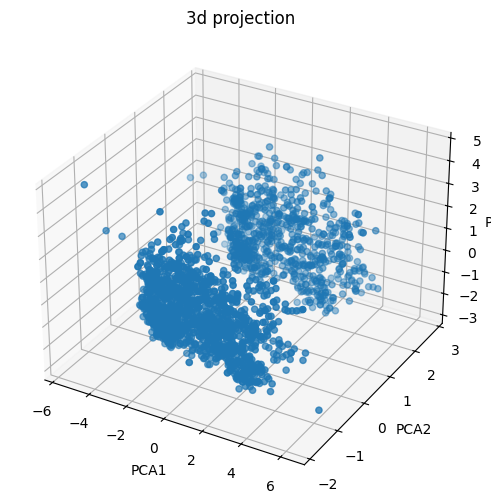

In [33]:
# plot
fig = plt.figure(figsize=(8,6))

ax = fig.add_subplot(111, projection="3d")

ax.scatter(X_pca[:,0],X_pca[:,1],X_pca[:,2])

ax.set_xlabel("PCA1")
ax.set_ylabel("PCA2")
ax.set_zlabel("PCA3")
ax.set_title("3d projection")

# Analyze K value

## 1. Elbow Method

In [34]:
from sklearn.cluster import KMeans
from kneed import KneeLocator

wcss = []
for k in range(2,11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit_predict(X_pca)
    wcss.append(kmeans.inertia_)

In [35]:
knee = KneeLocator(range(2, 11), wcss, curve="convex", direction="decreasing")
optimal_knee = knee.elbow

In [36]:
print(f"best K value : {optimal_knee}")

best K value : 5


Text(0, 0.5, 'WCSS')

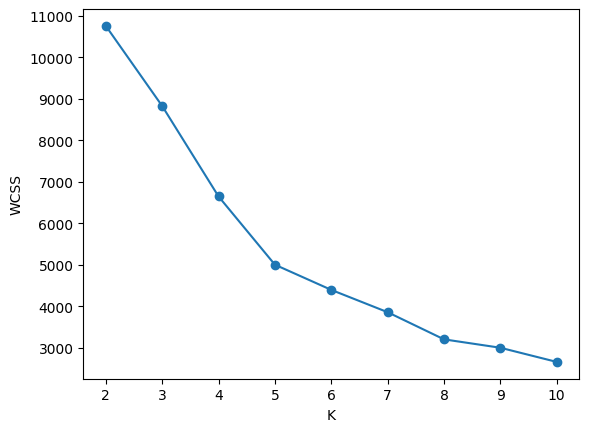

In [37]:
# plot

plt.plot(range(2, 11), wcss, marker='o')
plt.xlabel("K")
plt.ylabel("WCSS")

## 2. Silhouette Method

In [38]:
from sklearn.metrics import silhouette_score

Text(0, 0.5, 'Silhouette score')

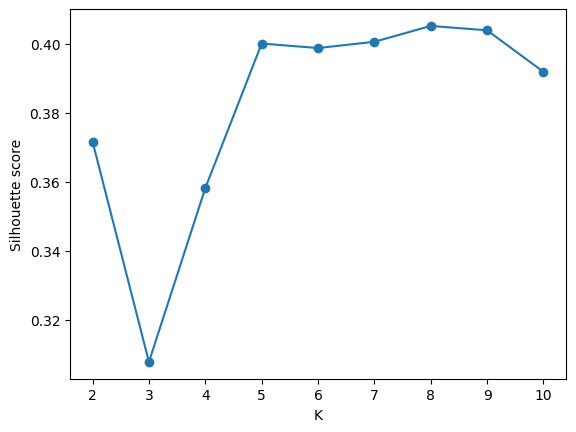

In [39]:
scores = []

for k in range(2,11):
    kmeans = KMeans(n_clusters=k,random_state=42)
    labels = kmeans.fit_predict(X_pca)
    score = silhouette_score(X_pca, labels)
    scores.append(score)

# plot
plt.plot(range(2, 11), scores, marker='o')
plt.xlabel("K")
plt.ylabel("Silhouette score")

Text(0, 0.5, 'SS')

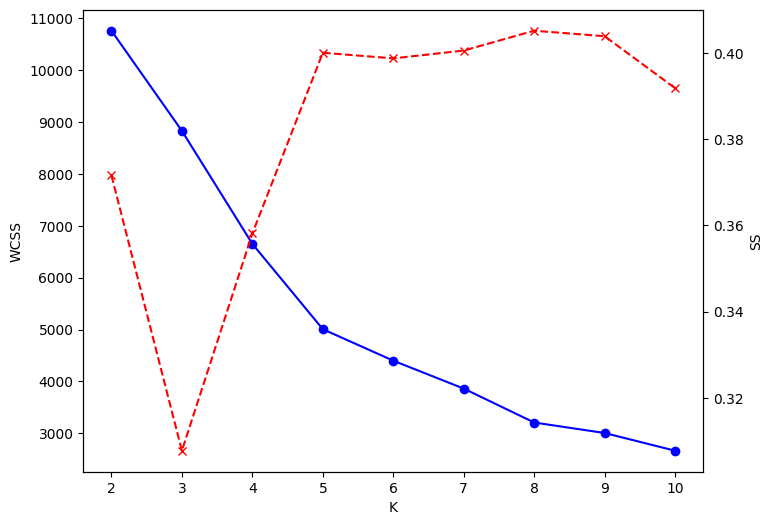

In [40]:
# combined plot

k_range = range(2, 11)

fig, ax1 = plt.subplots(figsize=(8, 6))

ax1.plot(k_range, wcss[:len(k_range)], marker="o", color="blue") 
ax1.set_xlabel("K")
ax1.set_ylabel("WCSS")

ax2 = ax1.twinx()  # FOR SAME X AXIS
ax2.plot(k_range, scores[:len(k_range)], marker="x", color="red", linestyle="--")
ax2.set_ylabel("SS")

# CLUSTERING

In [41]:
kmeans = KMeans(n_clusters=4, random_state=42)
labels_kmeans = kmeans.fit_predict(X_pca)

In [42]:
labels_kmeans

array([2, 3, 2, ..., 2, 1, 1], shape=(2236,), dtype=int32)

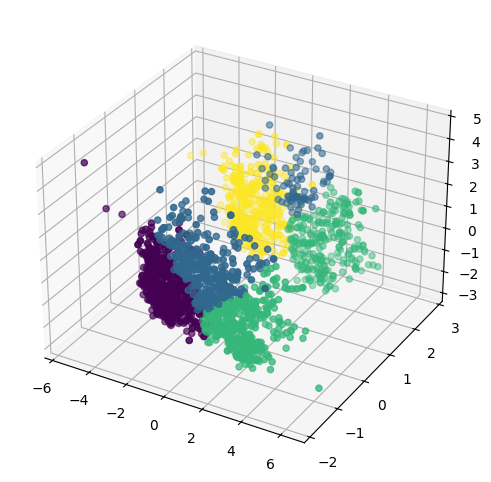

In [43]:
fig = plt.figure(figsize=(8, 6))

ax = fig.add_subplot(111, projection="3d")

ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2], c=labels_kmeans)

In [44]:
# Agglomerative clustering
from sklearn.cluster import AgglomerativeClustering

In [45]:
aggcls = AgglomerativeClustering(n_clusters=4, linkage= "ward")
labels_agglo = aggcls.fit_predict(X_pca)

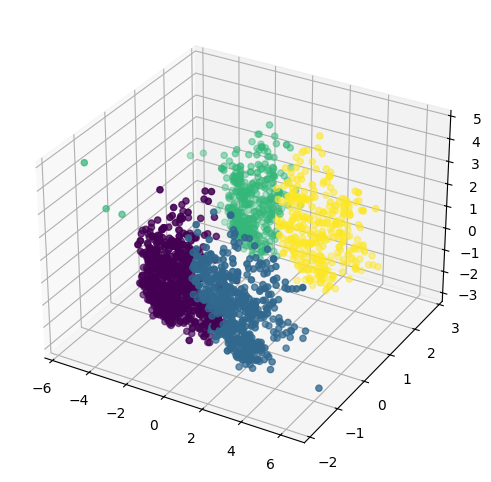

In [46]:
fig = plt.figure(figsize=(8, 6))

ax = fig.add_subplot(111, projection="3d")

ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2], c=labels_agglo)

# Characterization of clusters

In [57]:
# USED THIS TO REMOVE UNWANTED COLUMN
#df_cleaned = df_cleaned.drop(columns={"labels"})

In [58]:
df_cleaned["clusters"] = labels_agglo

In [59]:
df_cleaned.head()

,Education,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Days_as_Customer,Age,Total_spending,total_children,Living_with,clusters
0,Graduate,58138.0,58,3,8,10,4,7,0,1,663,57,1617,0,Alone,3
1,Graduate,46344.0,38,2,1,1,2,5,0,0,113,60,27,2,Alone,2
2,Graduate,71613.0,26,1,8,2,10,4,0,0,312,49,776,0,Partner,1
3,Graduate,26646.0,26,2,2,0,4,6,0,0,139,30,53,1,Partner,0
4,PostGraduate,58293.0,94,5,5,3,6,5,0,0,161,33,422,1,Partner,0


<Axes: xlabel='clusters', ylabel='count'>

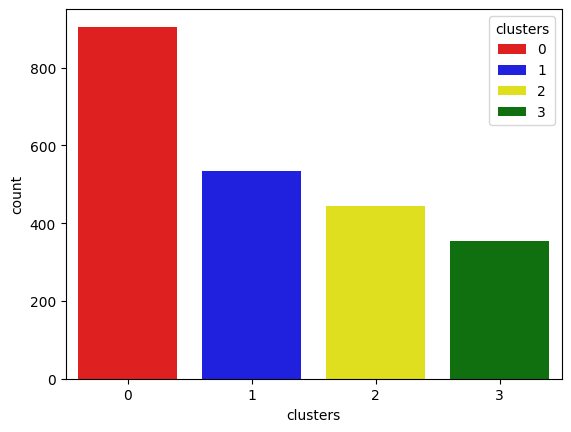

In [60]:
pal = ["red", "blue", "yellow", "green"]

sns.countplot(x=df_cleaned["clusters"], palette=pal, hue=df_cleaned["clusters"])

<Axes: xlabel='Total_spending', ylabel='Income'>

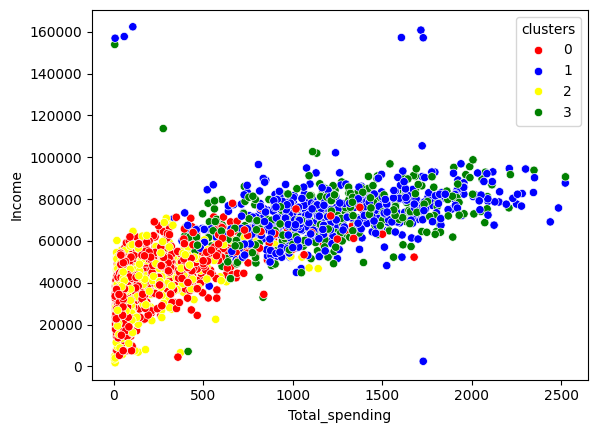

In [63]:
# Income & Spending patterns

sns.scatterplot(x=df_cleaned["Total_spending"], y=df_cleaned["Income"], hue=df_cleaned["clusters"], palette=pal)

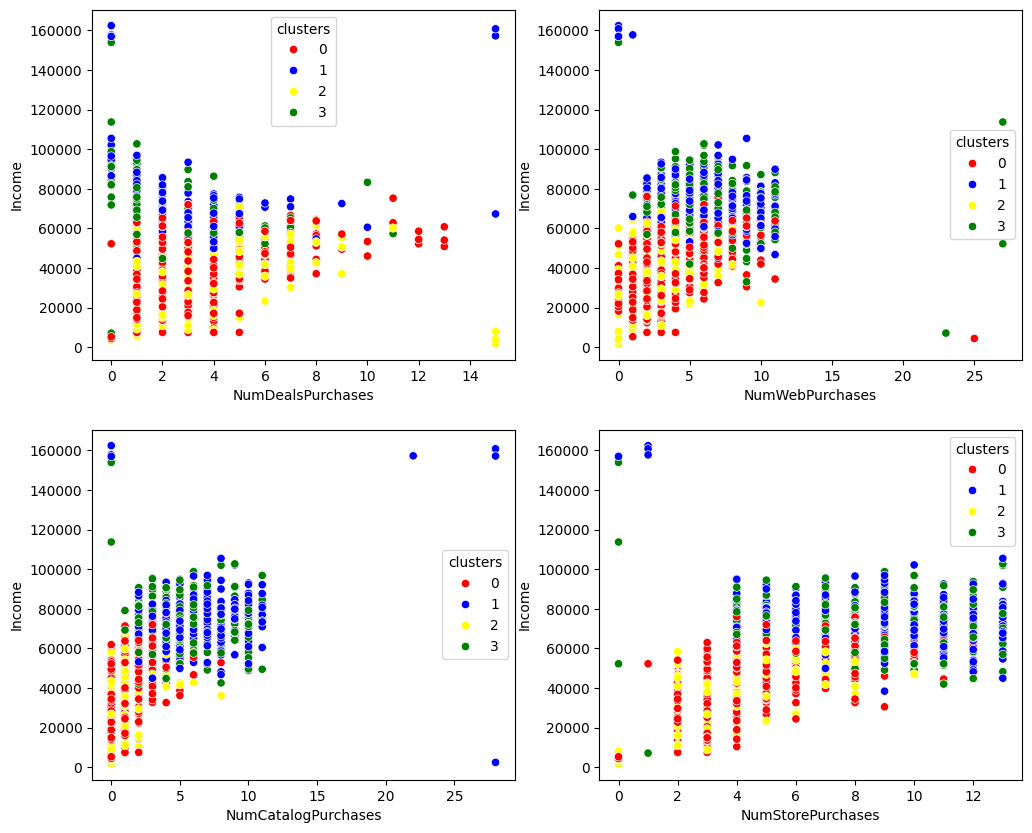

In [89]:
# plot multiple scatterplots comparing with INCOME
fig , axes = plt.subplots(nrows=2, ncols=2, figsize=(12,10))

ax1 = sns.scatterplot(x=df_cleaned["NumDealsPurchases"],y=df_cleaned["Income"],hue=df_cleaned["clusters"], palette=pal,ax=axes[0,0])

ax2 = sns.scatterplot(x=df_cleaned["NumWebPurchases"],y=df_cleaned["Income"],hue=df_cleaned["clusters"], palette=pal,ax=axes[0,1])

ax3 = sns.scatterplot(x=df_cleaned["NumCatalogPurchases"],y=df_cleaned["Income"],hue=df_cleaned["clusters"], palette=pal,ax=axes[1,0])

ax4 = sns.scatterplot(x=df_cleaned["NumStorePurchases"],y=df_cleaned["Income"],hue=df_cleaned["clusters"], palette=pal,ax=axes[1,1])

In [68]:
df_encoded["clusters"] = df_cleaned["clusters"]

In [69]:
# cluster summary

cluster_summary = df_encoded.groupby("clusters").mean()

In [70]:
cluster_summary

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Days_as_Customer,Age,Total_spending,total_children,Education_Graduate,Education_PostGraduate,Education_UnderGraduate,Living_with_Alone,Living_with_Partner
clusters,,,,,,,,,,,,,,,,,,
0,39690.146424,48.914917,2.594475,3.153591,0.969061,4.143646,6.307182,0.011050,0.076243,342.939227,43.669613,221.955801,1.243094,0.514917,0.338122,0.146961,0.000000,1.000000
1,72814.930722,49.202247,1.958801,5.687266,5.498127,8.659176,3.580524,0.005618,0.166667,369.720974,47.492509,1236.588015,0.511236,0.471910,0.455056,0.073034,0.000000,1.000000
2,36973.792251,48.319820,2.594595,2.713964,0.837838,3.623874,6.659910,0.011261,0.141892,338.781532,43.691441,165.702703,1.272523,0.488739,0.378378,0.132883,0.993243,0.006757
3,70730.038963,50.504249,1.855524,5.790368,5.014164,8.430595,3.728045,0.005666,0.320113,376.280453,46.932011,1190.385269,0.461756,0.541076,0.390935,0.067989,1.000000,0.000000
